# Motivation

## Tabular data
* sklearn


### IRIS

In [12]:
from sklearn.datasets import load_iris
blob = load_iris(as_frame= True)


In [13]:
X,y = blob.data, blob.target

In [14]:
X.sample(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
40,5.0,3.5,1.3,0.3
105,7.6,3.0,6.6,2.1
93,5.0,2.3,3.3,1.0
119,6.0,2.2,5.0,1.5
61,5.9,3.0,4.2,1.5
110,6.5,3.2,5.1,2.0
74,6.4,2.9,4.3,1.3
88,5.6,3.0,4.1,1.3
28,5.2,3.4,1.4,0.2
15,5.7,4.4,1.5,0.4


In [15]:
X.shape, y.shape

((150, 4), (150,))

In [17]:
blob.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [18]:
y.sample(5)

,target
54,1
63,1
4,0
103,2
25,0


In [19]:
blob.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

### BBC-News

In [20]:
# https://drive.google.com/file/d/1Rn5yjsOpA6MGNvFnmarIcD3Bb2u2wniO/view?usp=drive_link
!rm -rf bbc-news.csv
!gdown --id 1Rn5yjsOpA6MGNvFnmarIcD3Bb2u2wniO

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1Rn5yjsOpA6MGNvFnmarIcD3Bb2u2wniO
To: /content/bbc-news.csv
100% 5.08M/5.08M [00:00<00:00, 193MB/s]


In [21]:
df = pd.read_csv("bbc-news.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2225 entries, 0 to 2224
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    2225 non-null   object
 1   label   2225 non-null   object
dtypes: object(2)
memory usage: 34.9+ KB


In [22]:
df.sample(4)

,text,label
1690,Preview: Ireland v England (Sun) Lansdowne Roa...,sport
1976,Movie body hits peer-to-peer nets The movie in...,tech
243,Warning over US pensions deficit Taxpayers may...,business
1213,Campaign 'cold calls' questioned Labour and th...,politics


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.datasets import fetch_openml
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42

In [24]:
print("Downloading / loading Adult from OpenML (cached after first run)...")
bunch = fetch_openml(data_id=1590, as_frame=True, parser="auto")
X = bunch.data
y = bunch.target

# Normalize target to binary labels 0/1
y_str = y.astype(str).str.strip()
print("Target uniques:", sorted(y_str.unique()))
y_bin = (y_str == ">50K").astype(int)

Target uniques: ['<=50K', '>50K']


In [25]:
X.sample(5)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
48256,25,Private,98155,Some-college,10,Never-married,Prof-specialty,Own-child,White,Male,0,0,40,United-States
26358,58,Private,225603,9th,5,Divorced,Farming-fishing,Not-in-family,Black,Male,0,0,40,United-States
712,44,Self-emp-inc,57233,Some-college,10,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States
34006,65,NaN,117963,HS-grad,9,Married-civ-spouse,NaN,Husband,White,Male,0,0,45,United-States
23103,32,Self-emp-not-inc,319280,Assoc-acdm,12,Never-married,Sales,Not-in-family,White,Male,0,0,80,United-States


In [26]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             48842 non-null  int64   
 1   workclass       46043 non-null  category
 2   fnlwgt          48842 non-null  int64   
 3   education       48842 non-null  category
 4   education-num   48842 non-null  int64   
 5   marital-status  48842 non-null  category
 6   occupation      46033 non-null  category
 7   relationship    48842 non-null  category
 8   race            48842 non-null  category
 9   sex             48842 non-null  category
 10  capital-gain    48842 non-null  int64   
 11  capital-loss    48842 non-null  int64   
 12  hours-per-week  48842 non-null  int64   
 13  native-country  47985 non-null  category
dtypes: category(8), int64(6)
memory usage: 2.6 MB


In [27]:
type(X)

pandas.core.frame.DataFrame

In [28]:
type(X.age)

pandas.core.series.Series

## Series

In [29]:
from sklearn.datasets import load_iris
blob = load_iris(as_frame= True)
X, y = blob.data, blob.target

In [30]:
list(X.columns)

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [31]:
col1 = X['sepal length (cm)']
type(col1)

pandas.core.series.Series

In [32]:
col1.shape

(150,)

In [33]:
len(col1)

150

In [34]:
len(X)

150

In [36]:
col1.values

array([5.1, 4.9, 4.7, 4.6, 5. , 5.4, 4.6, 5. , 4.4, 4.9, 5.4, 4.8, 4.8,
       4.3, 5.8, 5.7, 5.4, 5.1, 5.7, 5.1, 5.4, 5.1, 4.6, 5.1, 4.8, 5. ,
       5. , 5.2, 5.2, 4.7, 4.8, 5.4, 5.2, 5.5, 4.9, 5. , 5.5, 4.9, 4.4,
       5.1, 5. , 4.5, 4.4, 5. , 5.1, 4.8, 5.1, 4.6, 5.3, 5. , 7. , 6.4,
       6.9, 5.5, 6.5, 5.7, 6.3, 4.9, 6.6, 5.2, 5. , 5.9, 6. , 6.1, 5.6,
       6.7, 5.6, 5.8, 6.2, 5.6, 5.9, 6.1, 6.3, 6.1, 6.4, 6.6, 6.8, 6.7,
       6. , 5.7, 5.5, 5.5, 5.8, 6. , 5.4, 6. , 6.7, 6.3, 5.6, 5.5, 5.5,
       6.1, 5.8, 5. , 5.6, 5.7, 5.7, 6.2, 5.1, 5.7, 6.3, 5.8, 7.1, 6.3,
       6.5, 7.6, 4.9, 7.3, 6.7, 7.2, 6.5, 6.4, 6.8, 5.7, 5.8, 6.4, 6.5,
       7.7, 7.7, 6. , 6.9, 5.6, 7.7, 6.3, 6.7, 7.2, 6.2, 6.1, 6.4, 7.2,
       7.4, 7.9, 6.4, 6.3, 6.1, 7.7, 6.3, 6.4, 6. , 6.9, 6.7, 6.9, 5.8,
       6.8, 6.7, 6.7, 6.3, 6.5, 6.2, 5.9])

In [37]:
type(col1.values)

numpy.ndarray

### indexing/slicing
* implict vs explicit
  * implicit = default/internal index

In [41]:
col1[0], col1.iloc[0]

(np.float64(5.1), np.float64(5.1))

In [42]:
col1[1], col1.iloc[1]

(np.float64(4.9), np.float64(4.9))

In [43]:
col1.iloc[:5]

,sepal length (cm)
0,5.1
1,4.9
2,4.7
3,4.6
4,5.0


In [44]:
col1.iloc[-5:]

,sepal length (cm)
145,6.7
146,6.3
147,6.5
148,6.2
149,5.9


In [45]:
col1.sample(5)

,sepal length (cm)
57,4.9
136,6.3
108,6.7
85,6.0
34,4.9


In [47]:
y.values


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [48]:
y.value_counts()

,count
target,
0,50
1,50
2,50


<Axes: xlabel='target'>

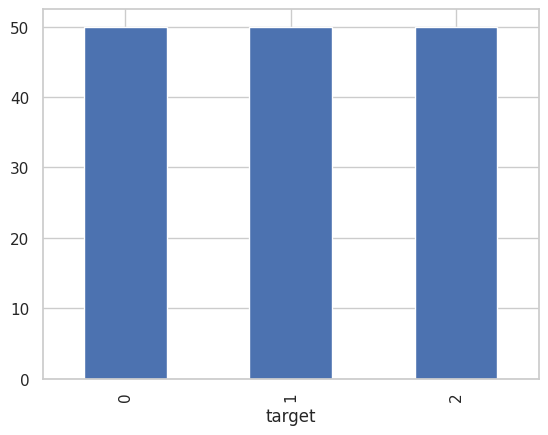

In [49]:
y.value_counts().plot(kind="bar")

### user-defined index

In [51]:
values = np.random.randint(0, 100, (10, ))
keys = np.random.randint(0, 100, (10, ))
print("values: "); print(values)
print("keys: "); print(keys)

values: 
[ 4 12 11 22 21 35 39 91  9 53]
keys: 
[41 46 76 21 38 22 22 92 37 76]


In [53]:
s = pd.Series(values, index=keys, name="ASeries")
s

,ASeries
41,4
46,12
76,11
21,22
38,21
22,35
22,39
92,91
37,9
76,53


In [57]:
s.iloc[0], s.loc[41]

(np.int64(4), np.int64(4))

In [58]:
s.iloc[1], s.loc[46]

(np.int64(12), np.int64(12))

In [61]:
print("s.iloc[0:4] :", s.iloc[0:4])   # implicit => exclusive
print("s.loc[41:44] :", s.loc[41:38]) # loc (user-defined) => inclusive

s.iloc[0:4] : 41     4
46    12
76    11
21    22
Name: ASeries, dtype: int64
s.loc[41:44] : 41     4
46    12
76    11
21    22
38    21
Name: ASeries, dtype: int64


In [63]:
L = list("ABCDE")
L

['A', 'B', 'C', 'D', 'E']

In [64]:
L[0:3]

['A', 'B', 'C']

In [65]:
A = np.random.randint(0, 100, (10, ))
A

array([19, 89, 22, 26, 84, 27, 68, 47,  8, 75])

In [66]:
A[0:4]

array([19, 89, 22, 26])

In [67]:
s.shape, len(s)

((10,), 10)

In [71]:
s.values

array([ 4, 12, 11, 22, 21, 35, 39, 91,  9, 53])

In [70]:
s.keys()

Index([41, 46, 76, 21, 38, 22, 22, 92, 37, 76], dtype='int64')

## DataFrame

In [72]:
T = np.random.randint(0, 100, (5, 4))
colnames = list("ABCD")
table = pd.DataFrame(T, columns=colnames)
table

,A,B,C,D
0,68,45,35,34
1,3,16,61,7
2,48,45,19,0
3,15,58,57,78
4,18,74,73,55


In [73]:
table.shape

(5, 4)

In [74]:
len(table)

5

In [75]:
V= table.values

In [76]:
type(V)

numpy.ndarray

### Info and Stats

In [77]:
table.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   A       5 non-null      int64
 1   B       5 non-null      int64
 2   C       5 non-null      int64
 3   D       5 non-null      int64
dtypes: int64(4)
memory usage: 292.0 bytes


In [84]:
table.describe()

,A,B,C,D
count,5.000000,5.000000,5.000000,5.000000
mean,30.400000,47.600000,49.000000,34.800000
std,26.763781,21.314314,21.679483,32.629741
min,3.000000,16.000000,19.000000,0.000000
25%,15.000000,45.000000,35.000000,7.000000
50%,18.000000,45.000000,57.000000,34.000000
75%,48.000000,58.000000,61.000000,55.000000
max,68.000000,74.000000,73.000000,78.000000


<Axes: >

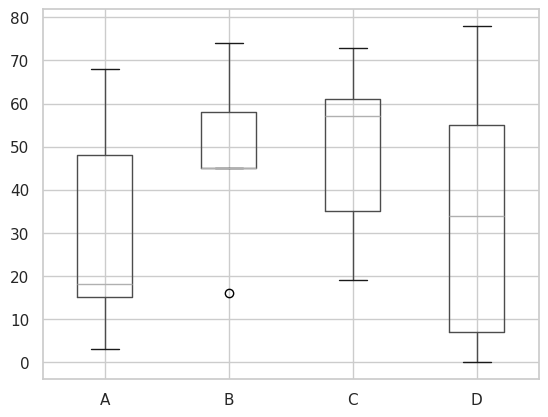

In [85]:
table.boxplot()

### like dictionary

In [86]:
table["A"]

,A
0,68
1,3
2,48
3,15
4,18


In [87]:
T

array([[68, 45, 35, 34],
       [ 3, 16, 61,  7],
       [48, 45, 19,  0],
       [15, 58, 57, 78],
       [18, 74, 73, 55]])

In [88]:
df = pd.DataFrame(
    {"A": T[:, 0],
     "B": T[:, 1]}
)

In [89]:
df

,A,B
0,68,45
1,3,16
2,48,45
3,15,58
4,18,74


In [90]:
D =  {"A": T[:, 0],
     "B": T[:, 1]}

In [91]:
D["A"]

array([68,  3, 48, 15, 18])

In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   A       5 non-null      int64
 1   B       5 non-null      int64
dtypes: int64(2)
memory usage: 212.0 bytes


In [93]:
df["A"]

,A
0,68
1,3
2,48
3,15
4,18


In [94]:
df.A

,A
0,68
1,3
2,48
3,15
4,18


In [95]:
D

{'A': array([68,  3, 48, 15, 18]), 'B': array([45, 16, 45, 58, 74])}

In [96]:
D["C"] = np.array([10, 20, 30])

In [98]:
df["C"] = np.array([10, 20, 30, 40, 50])

In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   A       5 non-null      int64
 1   B       5 non-null      int64
 2   C       5 non-null      int64
dtypes: int64(3)
memory usage: 252.0 bytes


In [100]:
df

,A,B,C
0,68,45,10
1,3,16,20
2,48,45,30
3,15,58,40
4,18,74,50


In [101]:
df.drop(columns=["C"], axis=1)

,A,B
0,68,45
1,3,16
2,48,45
3,15,58
4,18,74


In [105]:
df[["A", "C"]]

,A,C
0,68,10
1,3,20
2,48,30
3,15,40
4,18,50


In [107]:
list(table.columns)

['A', 'B', 'C', 'D']

In [108]:
table.iloc[:4]

,A,B,C,D
0,68,45,35,34
1,3,16,61,7
2,48,45,19,0
3,15,58,57,78


In [109]:
table.iloc[:2]

,A,B,C,D
0,68,45,35,34
1,3,16,61,7


In [114]:
table.iloc[:4][["A", "B"]]

,A,B
0,68,45
1,3,16
2,48,45
3,15,58


### missing values

In [115]:
dirty = pd.DataFrame(
    {
        "id": [1, 2, 2, 3],
        "score": [10.0, np.nan, 20.0, 15.0],
    }
)
print("row duplicated mask:", dirty.duplicated().tolist())
display(dirty.drop_duplicates(subset=["id"], keep="last"))
display(dirty.dropna(subset=["score"]))  # rows with known score
display(dirty["score"].fillna(dirty["score"].median()))  # impute without dropping rows

row duplicated mask: [False, False, False, False]


,id,score
0,1,10.0
2,2,20.0
3,3,15.0


,id,score
0,1,10.0
2,2,20.0
3,3,15.0


,score
0,10.0
1,15.0
2,20.0
3,15.0


In [116]:
dirty

,id,score
0,1,10.0
1,2,NaN
2,2,20.0
3,3,15.0


In [117]:
dirty.dropna(subset=["score"])

,id,score
0,1,10.0
2,2,20.0
3,3,15.0
